In [25]:
import os
import rasterio
import numpy as np
from rasterio.warp import reproject, Resampling
from pyproj import Transformer

DATA_DIR = r"H:\My Drive\Landslide_data"
PATCH = 64
STRIDE = 32

REMOVE_BANDS = []
TEST_EVENTS = 3

X_train, y_train, coords_train = [], [], []
X_test, y_test, coords_test = [], [], []

# =========================
# FIND FILE
# =========================
def find(prefix, folder_path, files):
    for f in files:
        if f.startswith(prefix) and f.endswith(".tif"):
            return os.path.join(folder_path, f)
    raise FileNotFoundError(prefix)

# =========================
# ALIGN TO REFERENCE
# =========================
def align_to_ref(src_path, ref_path, resampling):
    src = rasterio.open(src_path)
    ref = rasterio.open(ref_path)

    dst = np.zeros((src.count, ref.height, ref.width), dtype=src.read(1).dtype)

    for i in range(src.count):
        reproject(
            source=src.read(i+1),
            destination=dst[i],
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref.transform,
            dst_crs=ref.crs,
            resampling=resampling
        )
    return dst

# =========================
# PATCH CORNER COORDS
# =========================
def get_patch_corners(transform, crs, i, j, patch):
    transformer = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)

    corners_px = [
        (j, i),                       # top-left
        (j + patch, i),               # top-right
        (j, i + patch),               # bottom-left
        (j + patch, i + patch)        # bottom-right
    ]

    corners_latlon = []
    for col, row in corners_px:
        x, y = transform * (col, row)
        lon, lat = transformer.transform(x, y)
        corners_latlon.append((lat, lon))

    return {
        "top_left": corners_latlon[0],
        "top_right": corners_latlon[1],
        "bottom_left": corners_latlon[2],
        "bottom_right": corners_latlon[3],
        "row": i,
        "col": j
    }

# =========================
# PROCESS FOLDER
# =========================
def process_folder(folder, X_list, y_list, coord_list):
    folder_path = os.path.join(DATA_DIR, folder)
    files = os.listdir(folder_path)

    ref_path = find("S2", folder_path, files)
    ref = rasterio.open(ref_path)

    transform = ref.transform
    crs = ref.crs

    # ---- ALIGN ALL DATA ----
    s2 = ref.read()
    s1 = align_to_ref(find("S1", folder_path, files), ref_path, Resampling.bilinear)
    soil = align_to_ref(find("SOIL", folder_path, files), ref_path, Resampling.bilinear)
    terrain = align_to_ref(find("TERRAIN", folder_path, files), ref_path, Resampling.bilinear)
    rain = align_to_ref(find("RAIN", folder_path, files), ref_path, Resampling.bilinear)

    label = align_to_ref(
        find("LABEL", folder_path, files),
        ref_path,
        Resampling.nearest
    )[0]

    # ---- STACK ----
    img = np.concatenate([s1, s2, soil, terrain, rain], axis=0)
    img = np.transpose(img, (1,2,0)).astype(np.float32)

    # ---- NORMALIZE ----
    for b in range(img.shape[2]):
        band = img[:,:,b]
        valid = ~np.isnan(band)
        if np.any(valid):
            min_val = band[valid].min()
            max_val = band[valid].max()
            den = max_val - min_val
            if den > 1e-6:
                img[:,:,b][valid] = (band[valid] - min_val) / den

    # ---- REMOVE BANDS ----
    keep = [i for i in range(img.shape[-1]) if i not in REMOVE_BANDS]
    img = img[:,:,keep]

    H, W, _ = img.shape

    # =========================
    # PATCH LOOP
    # =========================
    for i in range(0, H - PATCH + 1, STRIDE):
        for j in range(0, W - PATCH + 1, STRIDE):

            patch = img[i:i+PATCH, j:j+PATCH]
            lbl = label[i:i+PATCH, j:j+PATCH]

            if lbl.sum() == 0:
                continue

            # adjust indices if needed
            diff = patch[:,:,9] - patch[:,:,5]

            mask = np.maximum(diff, 0) * lbl
            mask = np.clip(mask, 0, 1)

            if (mask > 0).sum() < 5:
                continue

            # ---- GET GEO COORDS ----
            coords = get_patch_corners(transform, crs, i, j, PATCH)

            X_list.append(patch)
            y_list.append(mask)
            coord_list.append(coords)

# =========================
# TRAIN TEST SPLIT
# =========================
folders = sorted([f for f in os.listdir(DATA_DIR) if f.startswith("LS_")])
train_folders = folders[:-TEST_EVENTS]
test_folders = folders[-TEST_EVENTS:]

for f in train_folders:
    process_folder(f, X_train, y_train, coords_train)

for f in test_folders:
    process_folder(f, X_test, y_test, coords_test)

# =========================
# FINAL ARRAYS
# =========================
X_train = np.array(X_train, dtype=np.float32)
y_train = np.array(y_train, dtype=np.float32)[..., None]

X_test = np.array(X_test, dtype=np.float32)
y_test = np.array(y_test, dtype=np.float32)[..., None]

# =========================
# REMOVE NaNs
# =========================
def remove_nan(X, y, coords):
    mask = ~np.isnan(X).any(axis=(1,2,3))
    return X[mask], y[mask], [coords[i] for i in range(len(coords)) if mask[i]]

X_train, y_train, coords_train = remove_nan(X_train, y_train, coords_train)
X_test, y_test, coords_test = remove_nan(X_test, y_test, coords_test)

# =========================
# OUTPUT
# =========================
print("Done")
print("Train:", X_train.shape, y_train.shape, len(coords_train))
print("Test:", X_test.shape, y_test.shape, len(coords_test))

# Example
print(coords_train[0])

Done
Train: (151, 64, 64, 23) (151, 64, 64, 1) 151
Test: (96, 64, 64, 23) (96, 64, 64, 1) 96
{'top_left': (11.366922279134778, 76.93315823645041), 'top_right': (11.366922279134778, 76.93890745426877), 'bottom_left': (11.361173061316412, 76.93315823645041), 'bottom_right': (11.361173061316412, 76.93890745426877), 'row': 480, 'col': 704}


In [13]:
REMOVE_BANDS = [8, 9, 10, 7, 12]

# keep indices
keep = [i for i in range(X_train.shape[3]) if i not in REMOVE_BANDS]

# apply to train and test
X_train = X_train[:, :, :, keep]
X_test  = X_test[:, :, :, keep]

In [14]:
threshold = 0.1  # adjust (try 0.01–0.05)

mask_fraction = y_train.reshape(y_train.shape[0], -1).sum(axis=1)

keep_idx = mask_fraction > threshold

X_train_filtered = X_train[keep_idx]
y_train_filtered = y_train[keep_idx]
coords_train_filtered = [
    coords_train[i] for i in range(len(coords_train)) if keep_idx[i]
]

print("Before:", X_train.shape[0])
print("After:", X_train_filtered.shape[0])


mask_fraction = y_test.reshape(y_test.shape[0], -1).sum(axis=1)

keep_idx = mask_fraction > threshold

X_test_filtered = X_test[keep_idx]
y_test_filtered = y_test[keep_idx]
coords_test_filtered = [
    coords_test[i] for i in range(len(coords_test)) if keep_idx[i]
]

print("Before:", X_test.shape[0])
print("After:", X_test_filtered.shape[0])

# mask_fraction = y.reshape(y.shape[0], -1).mean(axis=1)

# threshold = 0.02  # adjust (try 0.01–0.05)

# keep_idx = mask_fraction > threshold

# X_filtered = X[keep_idx]
# y_filtered = y[keep_idx]

# print("Before:", X.shape[0])
# print("After:", X_filtered.shape[0])


Before: 151
After: 150
Before: 96
After: 96


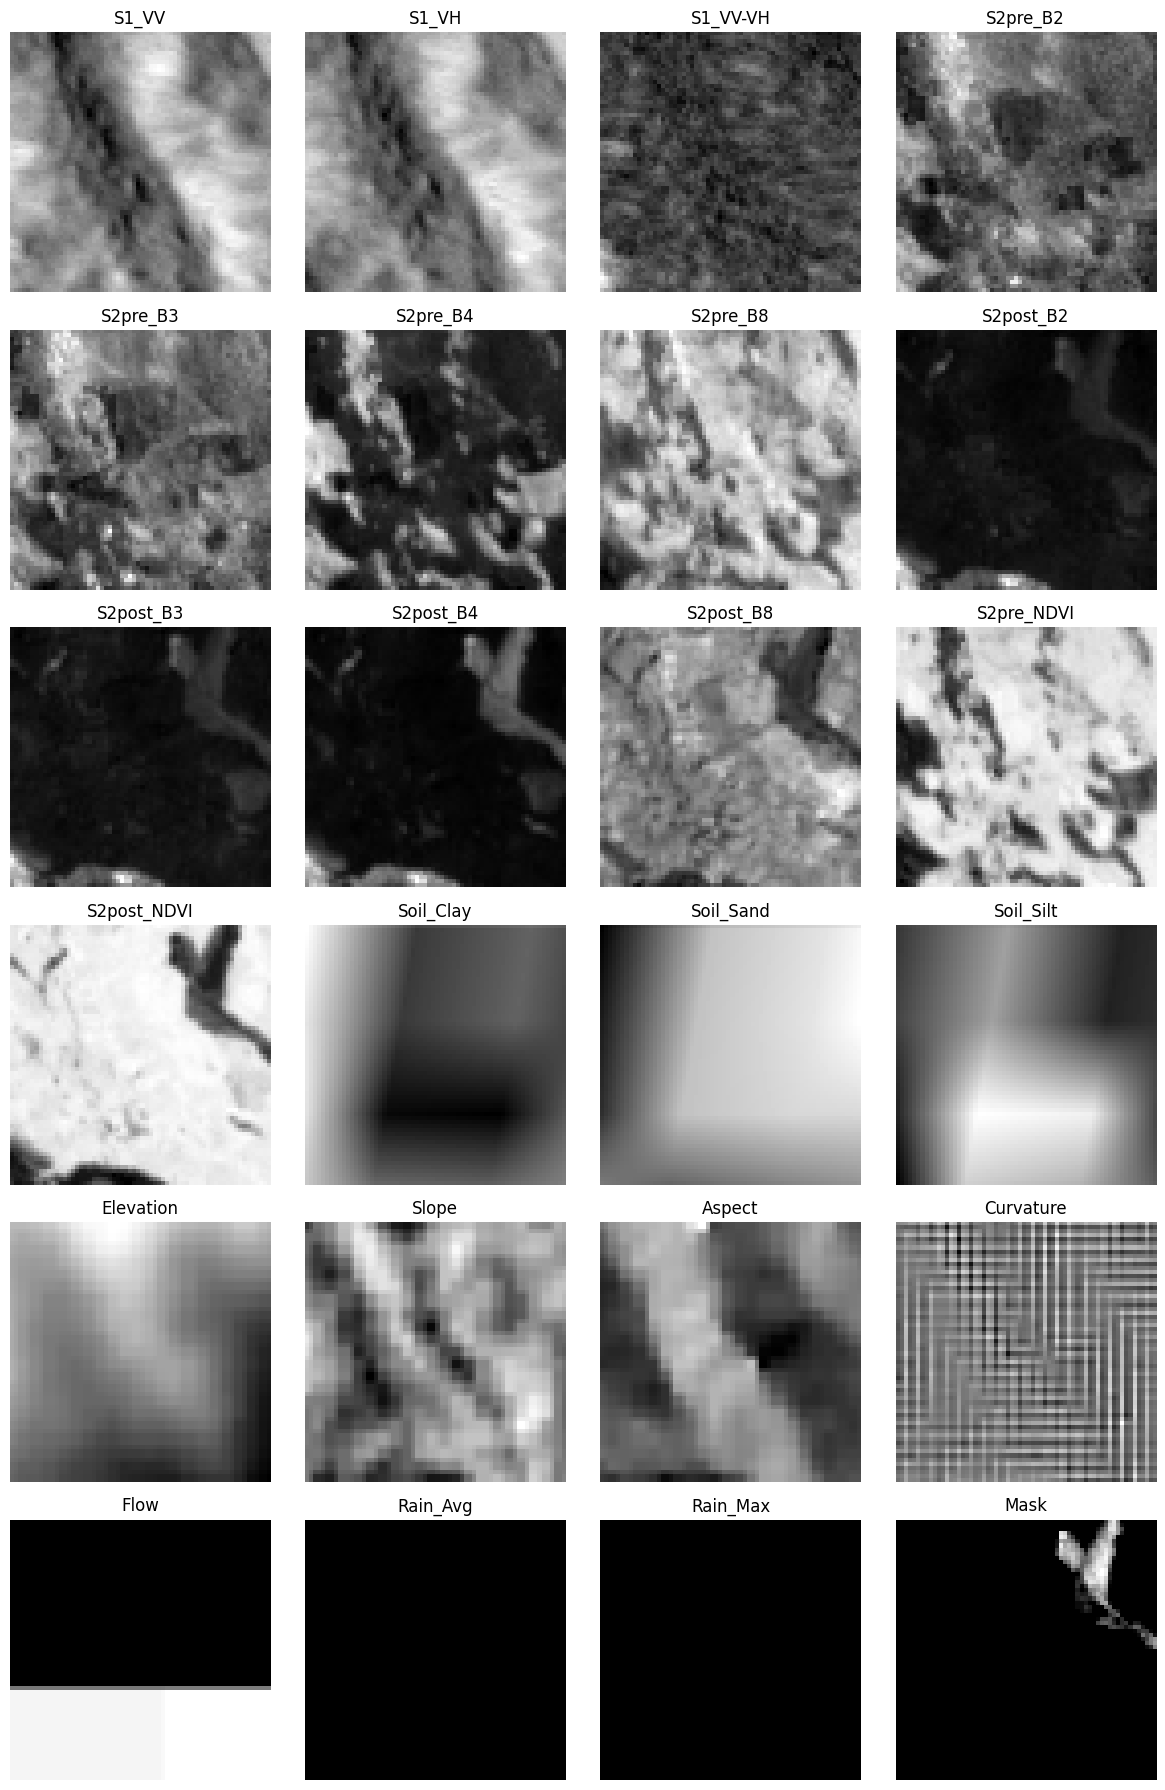

In [26]:
band_names_full = [
    "S1_VV", "S1_VH", "S1_VV-VH",

    "S2pre_B2", "S2pre_B3", "S2pre_B4", "S2pre_B8",

    "S2post_B2", "S2post_B3", "S2post_B4", "S2post_B8", "S2pre_NDVI", "S2post_NDVI",

    "Soil_Clay", "Soil_Sand", "Soil_Silt",

    "Elevation", "Slope", "Aspect", "Curvature", "Flow",

    "Rain_Avg", "Rain_Max"
]

keep = [i for i in range(len(band_names_full)) if i not in REMOVE_BANDS]
band_names = [band_names_full[i] for i in keep]

import matplotlib.pyplot as plt

i = 140

X = X_train
y = y_train

num_bands = X.shape[3]
cols = 4
rows = (num_bands + 1 + cols - 1) // cols

plt.figure(figsize=(12, 3*rows))

for b in range(num_bands):
    plt.subplot(rows, cols, b + 1)
    plt.imshow(X[i][:,:,b], cmap='gray')
    plt.title(band_names[b])   # ✅ actual name
    plt.axis('off')

# Mask
plt.subplot(rows, cols, num_bands + 1)
plt.imshow(y[i][:,:,0], cmap='gray')
plt.title('Mask')
plt.axis('off')

plt.tight_layout()
plt.show()

In [16]:
np.save('X_train3.npy', X_train_filtered)
np.save('y_train3.npy', y_train_filtered)

np.save('X_test3.npy', X_test_filtered)
np.save('y_test3.npy', y_test_filtered)

np.save("coords_train3.npy", np.array(coords_train_filtered, dtype=object))
np.save("coords_test3.npy", np.array(coords_test_filtered, dtype=object))

In [19]:
!pip install scipy

  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl (41.3 MB)


In [21]:
import os
import rasterio
import pandas as pd
import numpy as np
from rasterio.warp import reproject, Resampling
from pyproj import Transformer
from scipy.ndimage import gaussian_filter

DATA_DIR = r"H:\My Drive\Landslide_data"
PATCH = 64
STRIDE = 32
TEST_EVENTS = 3

X_train, y_train, coords_train = [], [], []
X_test, y_test, coords_test = [], [], []

# =========================
# FIND FILE
# =========================
def find(prefix, folder_path, files):
    for f in files:
        if f.startswith(prefix) and f.endswith(".tif"):
            return os.path.join(folder_path, f)
    raise FileNotFoundError(prefix)

# =========================
# ALIGN TO REFERENCE
# =========================
def align_to_ref(src_path, ref, resampling):
    src = rasterio.open(src_path)

    dst = np.zeros((src.count, ref.height, ref.width), dtype=src.dtypes[0])

    for i in range(src.count):
        reproject(
            source=src.read(i+1),
            destination=dst[i],
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref.transform,
            dst_crs=ref.crs,
            resampling=resampling
        )
    return dst

# =========================
# PATCH CORNER COORDS
# =========================
def get_patch_corners(transform, transformer, i, j, patch):
    corners_px = [
        (j, i),
        (j + patch, i),
        (j, i + patch),
        (j + patch, i + patch)
    ]

    coords = []
    for col, row in corners_px:
        x, y = transform * (col, row)
        lon, lat = transformer.transform(x, y)
        coords.append((lat, lon))

    return {
        "top_left": coords[0],
        "top_right": coords[1],
        "bottom_left": coords[2],
        "bottom_right": coords[3],
        "row": i,
        "col": j
    }

# =========================
# LOAD LANDSLIDE POINTS
# =========================
def load_points(df, ref_crs):
    transformer = Transformer.from_crs("EPSG:4326", ref_crs, always_xy=True)
    xs, ys = transformer.transform(df["Longitude"].values,
                                   df["Latitude"].values)
    return np.vstack([xs, ys]).T

# =========================
# PROCESS FOLDER
# =========================
def process_folder(folder, X_list, y_list, coord_list, points):
    folder_path = os.path.join(DATA_DIR, folder)
    files = os.listdir(folder_path)

    ref_path = find("S2", folder_path, files)

    with rasterio.open(ref_path) as ref:
        transform = ref.transform
        crs = ref.crs
        transformer = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)

        # ---- ALIGN ALL DATA ----
        s2 = ref.read()
        s1 = align_to_ref(find("S1", folder_path, files), ref, Resampling.bilinear)
        soil = align_to_ref(find("SOIL", folder_path, files), ref, Resampling.bilinear)
        terrain = align_to_ref(find("TERRAIN", folder_path, files), ref, Resampling.bilinear)
        rain = align_to_ref(find("RAIN", folder_path, files), ref, Resampling.bilinear)

        label = align_to_ref(
            find("LABEL", folder_path, files),
            ref,
            Resampling.nearest
        )[0]

    # ---- STACK ----
    img = np.concatenate([s1, s2, soil, terrain, rain], axis=0)
    img = np.transpose(img, (1,2,0)).astype(np.float32)

    # ---- NORMALIZE ----
    for b in range(img.shape[2]):
        band = img[:,:,b]
        valid = ~np.isnan(band)
        if np.any(valid):
            min_val = band[valid].min()
            max_val = band[valid].max()
            den = max_val - min_val
            if den > 1e-6:
                img[:,:,b][valid] = (band[valid] - min_val) / den

    H, W, _ = img.shape

    # =========================
    # GLOBAL DENSITY MAP
    # =========================
    xs, ys = points[:,0], points[:,1]
    rows, cols = rasterio.transform.rowcol(transform, xs, ys)

    density_full = np.zeros((H, W), dtype=np.float32)

    for r, c in zip(rows, cols):
        if 0 <= r < H and 0 <= c < W:
            density_full[r, c] += 1

    density_full = gaussian_filter(density_full, sigma=10)

    if density_full.max() > 0:
        density_full /= density_full.max()

    # =========================
    # PATCH LOOP
    # =========================
    for i in range(0, H - PATCH + 1, STRIDE):
        for j in range(0, W - PATCH + 1, STRIDE):

            patch = img[i:i+PATCH, j:j+PATCH]
            lbl = label[i:i+PATCH, j:j+PATCH]

            if lbl.sum() == 0:
                continue

            # =========================
            # DENSITY (3× PATCH CONTEXT)
            # =========================
            half = PATCH

            r0 = max(i - half, 0)
            r1 = min(i + 2*PATCH, H)

            c0 = max(j - half, 0)
            c1 = min(j + 2*PATCH, W)

            d_big = density_full[r0:r1, c0:c1]

            d_patch = d_big[
                (i - r0):(i - r0 + PATCH),
                (j - c0):(j - c0 + PATCH)
            ]

            d_patch = d_patch[..., None]

            # ADD DENSITY CHANNEL
            patch = np.concatenate([patch, d_patch], axis=2)

            # =========================
            # ORIGINAL LOGIC (UNCHANGED)
            # =========================
            diff = patch[:,:,9] - patch[:,:,5]

            mask = np.maximum(diff, 0) * lbl
            mask = np.clip(mask, 0, 1)

            if (mask > 0).sum() < 5:
                continue

            coords = get_patch_corners(transform, transformer, i, j, PATCH)

            X_list.append(patch)
            y_list.append(mask)
            coord_list.append(coords)

# =========================
# MAIN EXECUTION
# =========================
folders = sorted([f for f in os.listdir(DATA_DIR) if f.startswith("LS_")])
train_folders = folders[:-TEST_EVENTS]
test_folders = folders[-TEST_EVENTS:]

# Load landslide inventory
df_points = pd.read_csv("Landslide_Inventory_Kerala_TN.csv")

# convert once using first folder CRS
sample_folder = os.path.join(DATA_DIR, folders[0])
sample_files = os.listdir(sample_folder)
sample_ref = rasterio.open(find("S2", sample_folder, sample_files))

points = load_points(df_points, sample_ref.crs)

# process
for f in train_folders:
    process_folder(f, X_train, y_train, coords_train, points)

for f in test_folders:
    process_folder(f, X_test, y_test, coords_test, points)

# =========================
# FINAL ARRAYS
# =========================
X_train = np.array(X_train, dtype=np.float32)
y_train = np.array(y_train, dtype=np.float32)[..., None]

X_test = np.array(X_test, dtype=np.float32)
y_test = np.array(y_test, dtype=np.float32)[..., None]

# =========================
# REMOVE NaNs
# =========================
def remove_nan(X, y, coords):
    mask = ~np.isnan(X).any(axis=(1,2,3))
    return X[mask], y[mask], [coords[i] for i in range(len(coords)) if mask[i]]

X_train, y_train, coords_train = remove_nan(X_train, y_train, coords_train)
X_test, y_test, coords_test = remove_nan(X_test, y_test, coords_test)

# =========================
# OUTPUT
# =========================
print("Done")
print("Train:", X_train.shape, y_train.shape, len(coords_train))
print("Test:", X_test.shape, y_test.shape, len(coords_test))

if len(coords_train) > 0:
    print(coords_train[0])

RasterioIOError: Read failed. See previous exception for details.

In [24]:
import rasterio

with rasterio.open(r"H:\My Drive\Landslide_data\LS_1\S2_1.tif") as src:
    print(src.read(1))

[[0.05515 0.0561  0.05585 ... 0.04115 0.0443  0.0496 ]
 [0.05555 0.04695 0.0455  ... 0.0408  0.044   0.0514 ]
 [0.053   0.04605 0.0435  ... 0.0407  0.0542  0.05775]
 ...
 [0.04335 0.05785 0.0617  ... 0.0909  0.0892  0.0913 ]
 [0.03295 0.03455 0.05105 ... 0.0785  0.0732  0.0732 ]
 [    nan     nan     nan ...     nan     nan     nan]]
